In [1]:
%matplotlib widget

Per ogni sorgente modificare:
- z e controllare che lambda lines corrisponda
- sigma e seeing
- n_component
- regione estrazione cielo
- taglio immagine in y
- funzioni di plot e model_convolved
- bounds_HA (ampiezza dell'intervallo sulle x è +- la metà del seeing) e bounds
- salvataggio fit

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/MGC+01-32-049/MCG+01-32-049_1/FORS2.2022-01-29T07_05_26.457/MCG+01-32-049_1_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/MGC+01-32-049/MCG+01-32-049_1/FORS2.2022-01-29T07_05_26.457/MCG+01-32-049_1_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     377   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        58   (2094, 964)   float32   


In [4]:
image_cut = image[52:172, 0:1890]
image_error_cut = image_error[52:172, 0:1890]

Text(0.5, 0, 'wavelength')

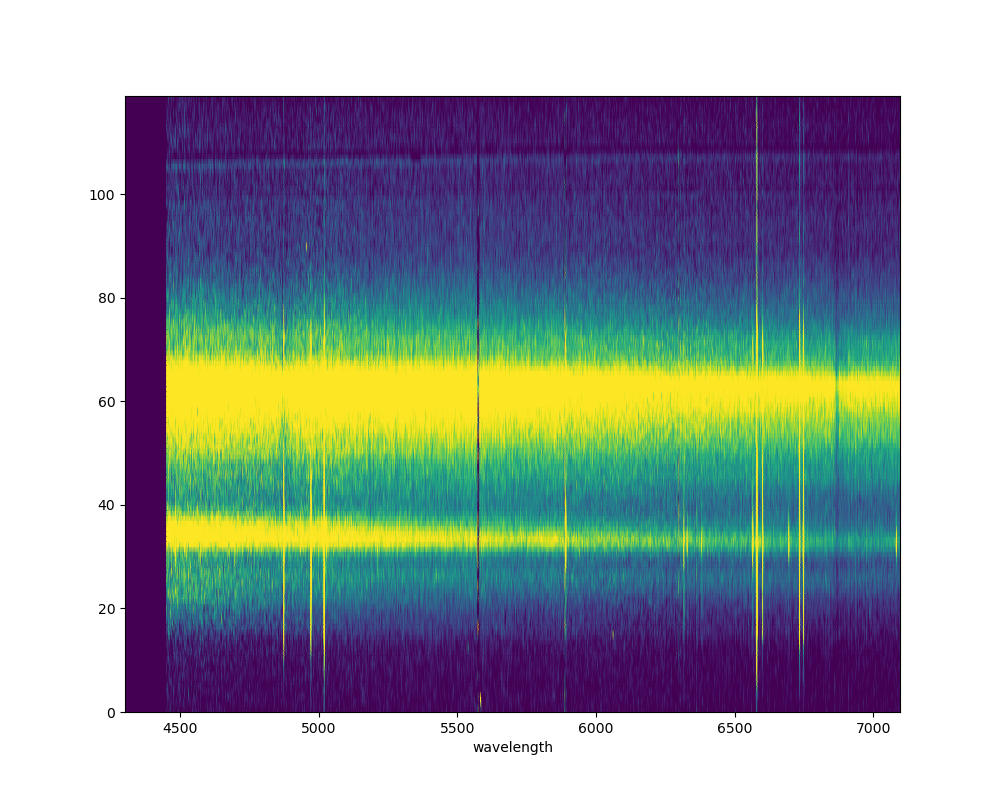

In [5]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10,8))
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin=np.percentile(image_cut, 15), vmax=np.percentile(image_cut, 90))
plt.xlabel('wavelength')

## Redshift or the lines in air

In [6]:
z = 0.00309
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/MGC+01-32-049\MCG+01-32-049_1/FORS2.2022-01-29T07_05_26.457/PSF/Real_seeing_MGC+01-32-049.txt")
sigmas = seeing / 2.35
print(sigmas)

[1.17687737 1.30227052 1.17372402 1.15290603 1.31110318 1.18212766]


In [7]:
l_NII

6603.34147

## Sky lines

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/MGC+01-32-049/MCG+01-32-049_1/FORS2.2022-01-29T07_05_26.457/MCG+01-32-049_1_MAPPED_FLUX_ALL_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     377   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        58   (2094, 964)   float32   


Text(0.5, 0, 'wavelength')

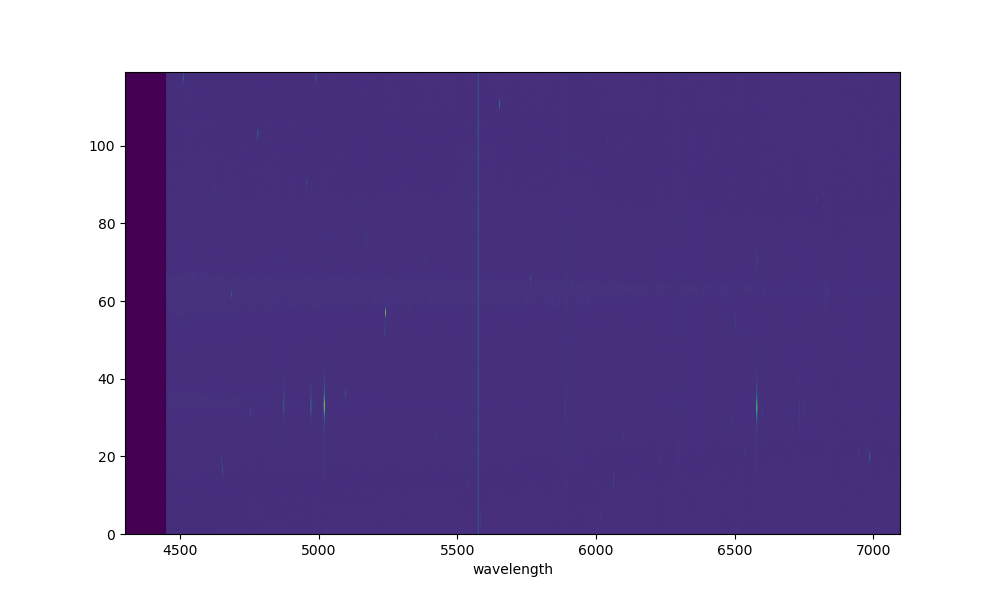

In [8]:
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/MGC+01-32-049/MCG+01-32-049_1/FORS2.2022-01-29T07_05_26.457/MCG+01-32-049_1_MAPPED_FLUX_ALL_SCI_LSS_U1.fits")
hdul2.info()
image2 = hdul2[0].data
image_cut2 = image2[52:172, 0:1890]

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10, 6))
plt.pcolormesh(x_grid, y_grid, image_cut2, shading='gouraud')#, vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelength')

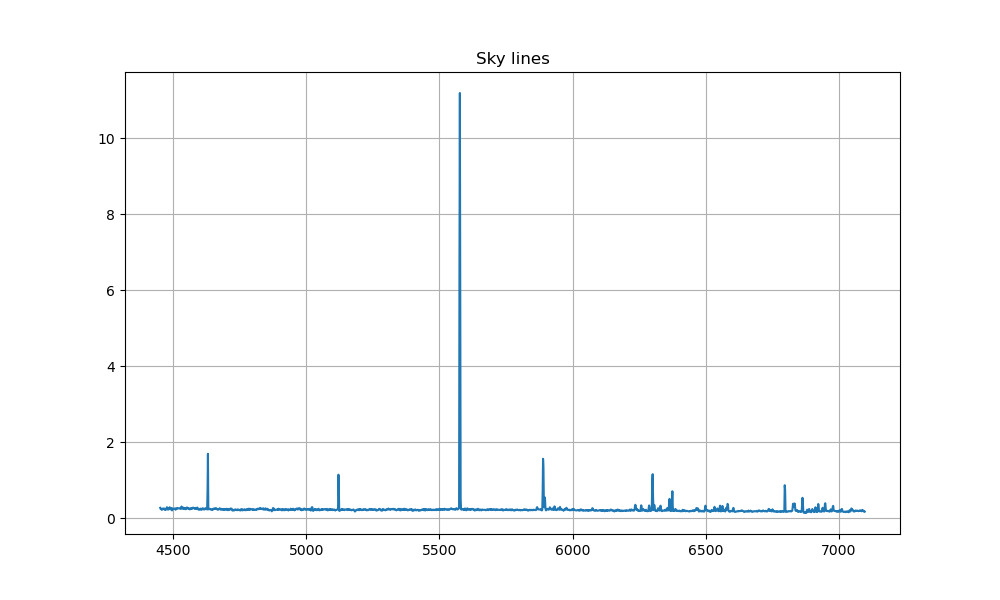

In [9]:
mask_sky = (y > 80)*(y < 90)
mask_wv = wv > 4451
image_sky = image_cut2[np.ix_(mask_sky, mask_wv)]
radial_profile_sky = np.sum(image_sky, axis = 0)
plt.figure(figsize=(10, 6))
plt.plot(wv[mask_wv], radial_profile_sky)

plt.grid()
plt.title(r'Sky lines')

plt.savefig('Sky_lines')

## H$\alpha$

Text(0.5, 1.0, 'H$\\alpha$')

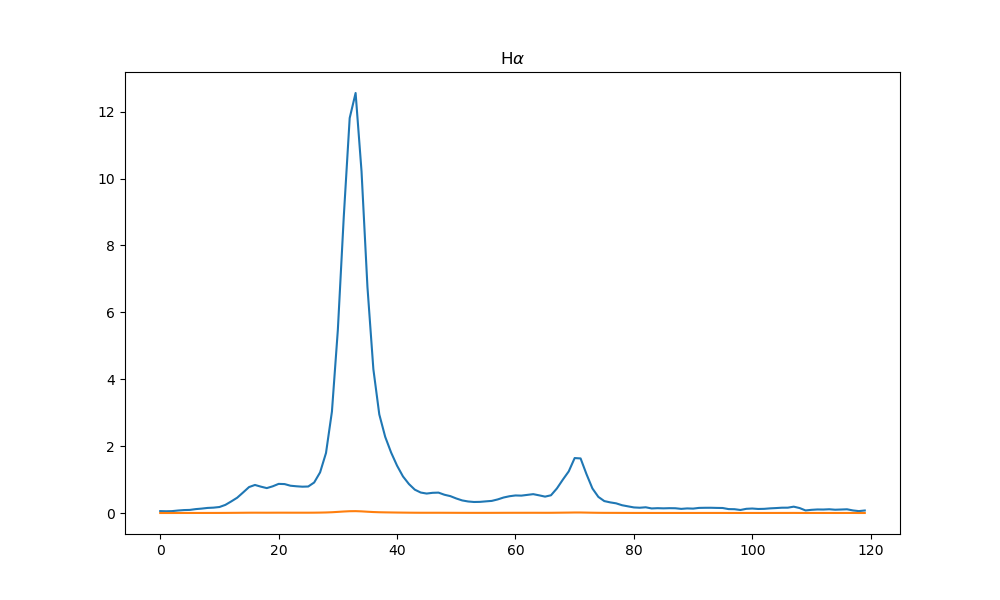

In [10]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

sky_err = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/MGC+01-32-049/MCG+01-32-049_1/FORS2.2022-01-29T07_05_26.457/Propag_errori/Sky_errors.txt")
real_errors_HA = np.sqrt(radial_profile_error_HA**2+(sky_err[2])**2+(0.04*radial_profile_HA)**2)

x_axes = np.arange(0, 120, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [40]:
n_component = 5

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, sigma, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])+
        sersic_1d(x_hr, *params[16:20]) #+
        #sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs, sigma):
    y_model = model_convolved(x, sigma, *params)
    return np.sum((y_obs - y_model)**2)

def sersic_1d_convolved(x, I_e, r_e, n, x_0, sigma):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 15)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 15)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

bounds_HA = [

    (0, 20),
    (0, 5),
    (0.1, 10),
    (15, 16),
    
    (0, 20),
    (0, 5),
    (0.1, 10),
    (20, 21),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (30, 35),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (62, 64),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (69, 71),
]

def save_params(params_curve, covariance, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, sigma, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, dof, chi2

def save_params_diff(params_curve, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    param_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    
    output_dir = "Diff_params"
    os.makedirs(output_dir, exist_ok=True)

    # Salva file CSV nella cartella Diff_params
    if line_name:
        param_filename = os.path.join(output_dir, f"{line_name}_{output_prefix}_diff.csv")
    
    df_params.to_csv(param_filename, float_format='%.4f')

In [13]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 17828.57666152546
differential_evolution step 2: f(x)= 17828.57666152546
differential_evolution step 3: f(x)= 17828.57666152546
differential_evolution step 4: f(x)= 17828.57666152546
differential_evolution step 5: f(x)= 5999.202808681327
differential_evolution step 6: f(x)= 2834.3244082910046
differential_evolution step 7: f(x)= 2834.3244082910046
differential_evolution step 8: f(x)= 2834.3244082910046
differential_evolution step 9: f(x)= 1843.1062131067847
differential_evolution step 10: f(x)= 1282.7292753427064
differential_evolution step 11: f(x)= 1282.7292753427064
differential_evolution step 12: f(x)= 1282.7292753427064
differential_evolution step 13: f(x)= 712.4067551840212
differential_evolution step 14: f(x)= 712.4067551840212
differential_evolution step 15: f(x)= 712.4067551840212
differential_evolution step 16: f(x)= 712.4067551840212
differential_evolution step 17: f(x)= 595.3811290726467
differential_evolution step 18: f(x)= 595.38112907

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15644\2221111526.py:11: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with differential_evolution:
Sérsic 1: I_e=14.3739, r_e=0.0222, n=7.3967, x_0=15.0727
Sérsic 2: I_e=0.5160, r_e=2.3958, n=0.1030, x_0=20.0010
Sérsic 3: I_e=1.7631, r_e=5.0074, n=1.5228, x_0=32.7260
Sérsic 4: I_e=0.0976, r_e=46.8680, n=0.9896, x_0=62.0550
Sérsic 5: I_e=0.0396, r_e=8.4222, n=3.1068, x_0=70.3393
Chi quadro minimo: 1.8253977194169844
False


Sérsic 1: I_e=14.3739, r_e=0.0222, n=7.3967, x_0=15.0727
Sérsic 2: I_e=0.5160, r_e=2.3958, n=0.1030, x_0=20.0010
Sérsic 3: I_e=1.7631, r_e=5.0074, n=1.5228, x_0=32.7260
Sérsic 4: I_e=0.0976, r_e=46.8680, n=0.9896, x_0=62.0550
Sérsic 5: I_e=0.0396, r_e=8.4222, n=3.1068, x_0=70.3393


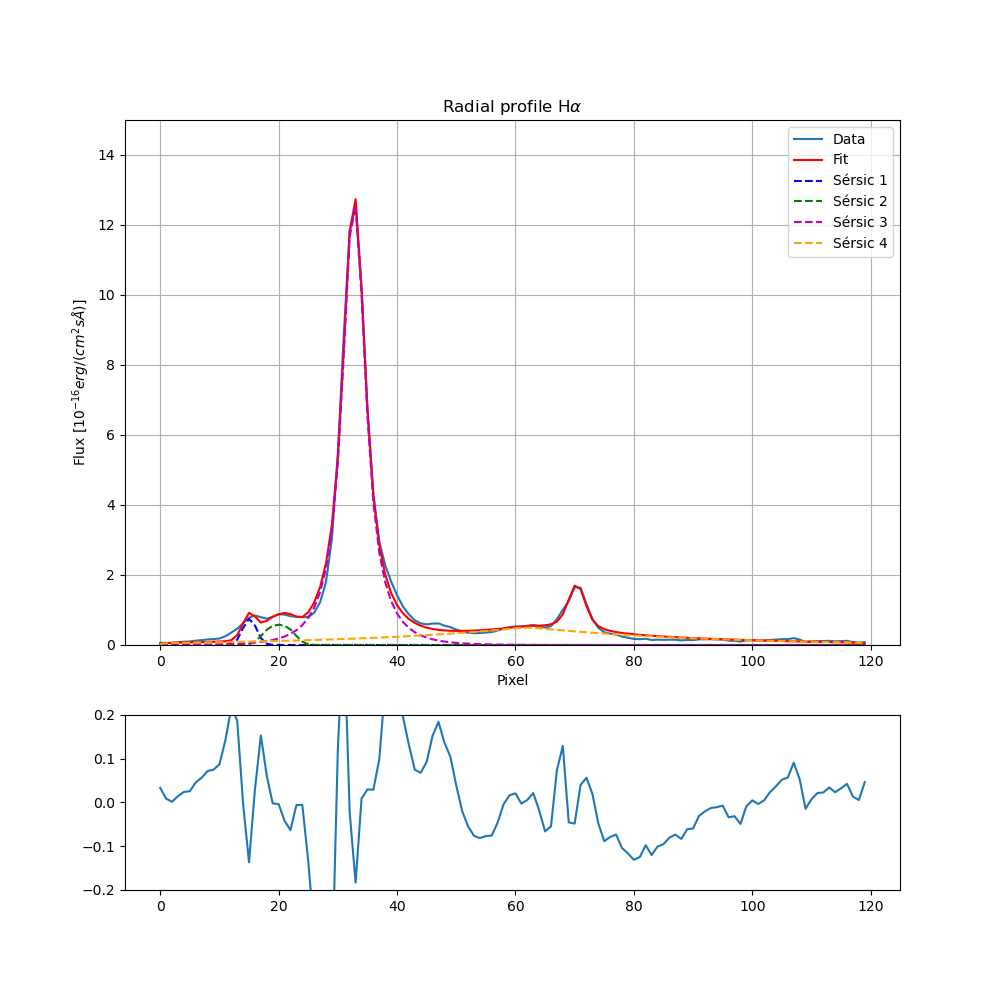

In [14]:
save_params_diff(best_params, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha_diff", output_prefix="fit")

plot_diff(x_axes, best_params, radial_profile_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_diff')

In [15]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HA, covariance_HA = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes, radial_profile_HA, p0=result.x, 
                                           sigma = real_errors_HA) #, bounds = bounds_list, maxfev= 10000)

print("Optimize parameters with curve fit:")

chi2_reduced_HA, dof_HA, chi2_HA = save_params(params_curve_HA, covariance_HA, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15644\2221111526.py:11: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15644\2221111526.py:11: RuntimeWarning: overflow encountered in exp
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15644\2221111526.py:24: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=7.6833, r_e=0.0225, n=204.8684, x_0=15.0672
Sérsic 2: I_e=0.0830, r_e=2.9530, n=0.0329, x_0=19.3838
Sérsic 3: I_e=0.6793, r_e=8.6865, n=2.3367, x_0=33.0144
Sérsic 4: I_e=0.0070, r_e=425.2507, n=2.4875, x_0=61.5681
Sérsic 5: I_e=0.4015, r_e=2.6085, n=1.0588, x_0=70.2791
[1.49055494e+05 2.18917018e+02 1.13530209e+06 3.15262800e-01
 2.12404966e+01 7.29798839e+00 2.34944422e+00 1.03789208e+00
 1.73185224e-01 1.32990255e+00 2.41447333e-01 7.28604363e-02
 1.09094435e-02 6.07971956e+02 9.95225024e-01 3.20097587e-02
 1.70986125e-01 5.68406988e-01 3.76705380e-01 1.22262984e-01]
5.76904022084431


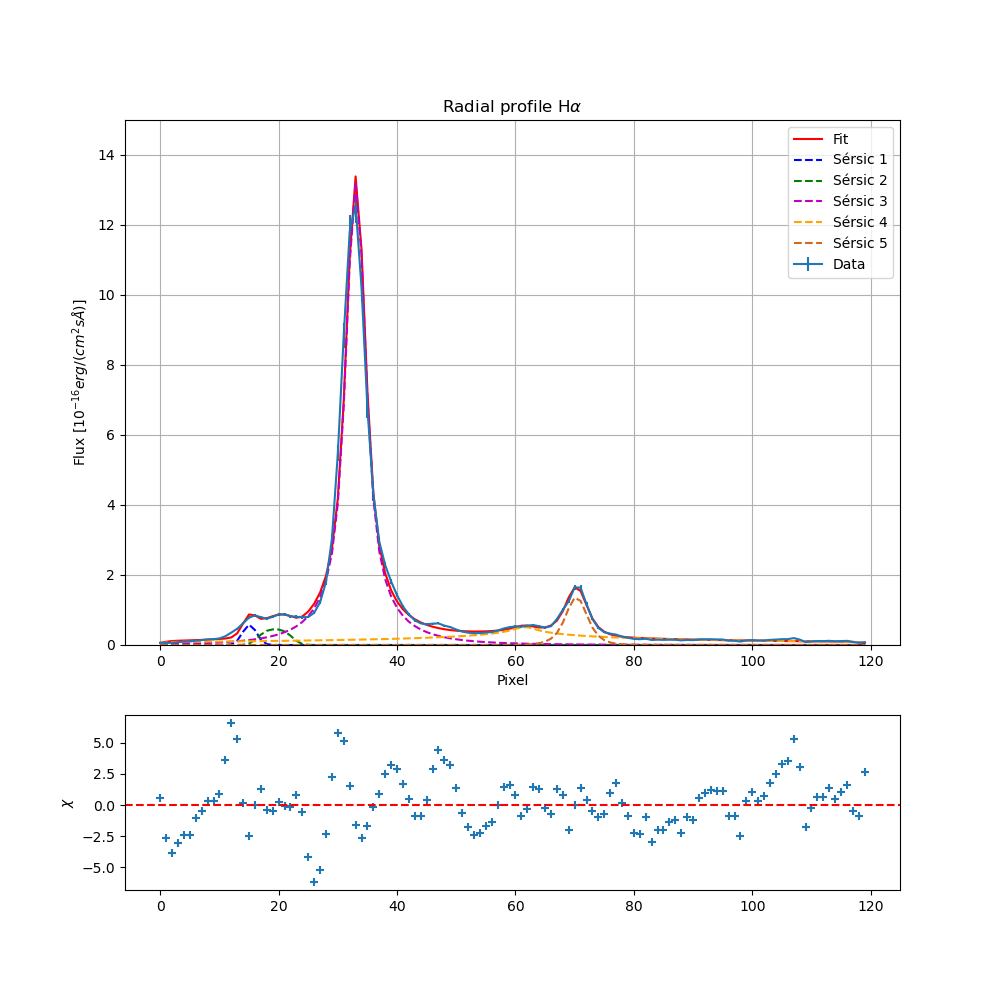

In [41]:
plot_curve(x_axes, params_curve_HA, radial_profile_HA, real_errors_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_curve')

In [17]:
fit_HA = pd.read_csv("Halpha_fit.csv", index_col=0)
x_0_HA = fit_HA.iloc[3].values
bounds = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 5),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1, x_0_HA[0]+1),   # x_0: circa la posizione di Halpha

    (0, 1),
    (0, 5),
    (0.1, 10),
    (x_0_HA[1]-1, x_0_HA[1]+1),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1, x_0_HA[2]+1),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-seeing[-1]/2, x_0_HA[3]+seeing[-1]/2),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[4]-seeing[-1]/2, x_0_HA[4]+seeing[-1]/2),
]

## H$\beta$

Text(0.5, 1.0, 'H$\\beta$')

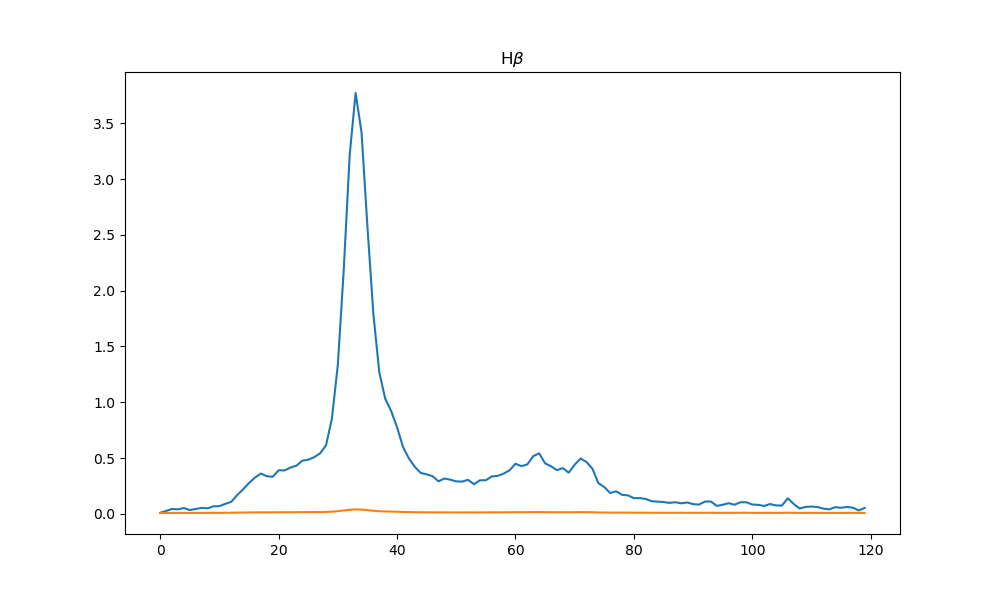

In [18]:
mask_HB = (wv > l_HB-8)*(wv < l_HB+8)
image_HB = image_cut[:, mask_HB] 
image_error_HB = image_error_cut[:, mask_HB]
radial_profile_HB = np.sum(image_HB, axis = 1)
radial_profile_error_HB = np.sqrt(np.sum(image_error_HB**2, axis = 1))
real_errors_HB = np.sqrt(radial_profile_error_HB**2+(sky_err[2])**2+(0.04*radial_profile_HB)**2)

plt.figure(figsize=(10, 6))
x_axes = np.arange(0, 120, 1)
plt.plot(x_axes, radial_profile_HB)
plt.plot(x_axes, radial_profile_error_HB)
plt.title(r'H$\beta$')

In [19]:
# Bounds:
bounds = bounds

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HB, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 5177.842515003817
differential_evolution step 2: f(x)= 3351.9525398591104
differential_evolution step 3: f(x)= 3351.9525398591104
differential_evolution step 4: f(x)= 3351.9525398591104
differential_evolution step 5: f(x)= 2100.945272005788
differential_evolution step 6: f(x)= 319.6102930617815
differential_evolution step 7: f(x)= 319.6102930617815
differential_evolution step 8: f(x)= 319.6102930617815
differential_evolution step 9: f(x)= 197.27675004204906
differential_evolution step 10: f(x)= 197.27675004204906
differential_evolution step 11: f(x)= 197.27675004204906
differential_evolution step 12: f(x)= 197.27675004204906
differential_evolution step 13: f(x)= 89.46864881550516
differential_evolution step 14: f(x)= 89.46864881550516
differential_evolution step 15: f(x)= 89.46864881550516
differential_evolution step 16: f(x)= 84.56944558817321
differential_evolution step 17: f(x)= 64.06081575903619
differential_evolution step 18: f(x)= 64.060815759

Sérsic 1: I_e=0.0852, r_e=1.3746, n=0.4078, x_0=15.1686
Sérsic 2: I_e=0.1359, r_e=3.7632, n=0.1000, x_0=19.8665
Sérsic 3: I_e=0.1741, r_e=12.3617, n=2.2909, x_0=33.2314
Sérsic 4: I_e=0.0430, r_e=49.4899, n=1.4557, x_0=62.9571
Sérsic 5: I_e=0.3396, r_e=0.2401, n=1.5368, x_0=71.5071


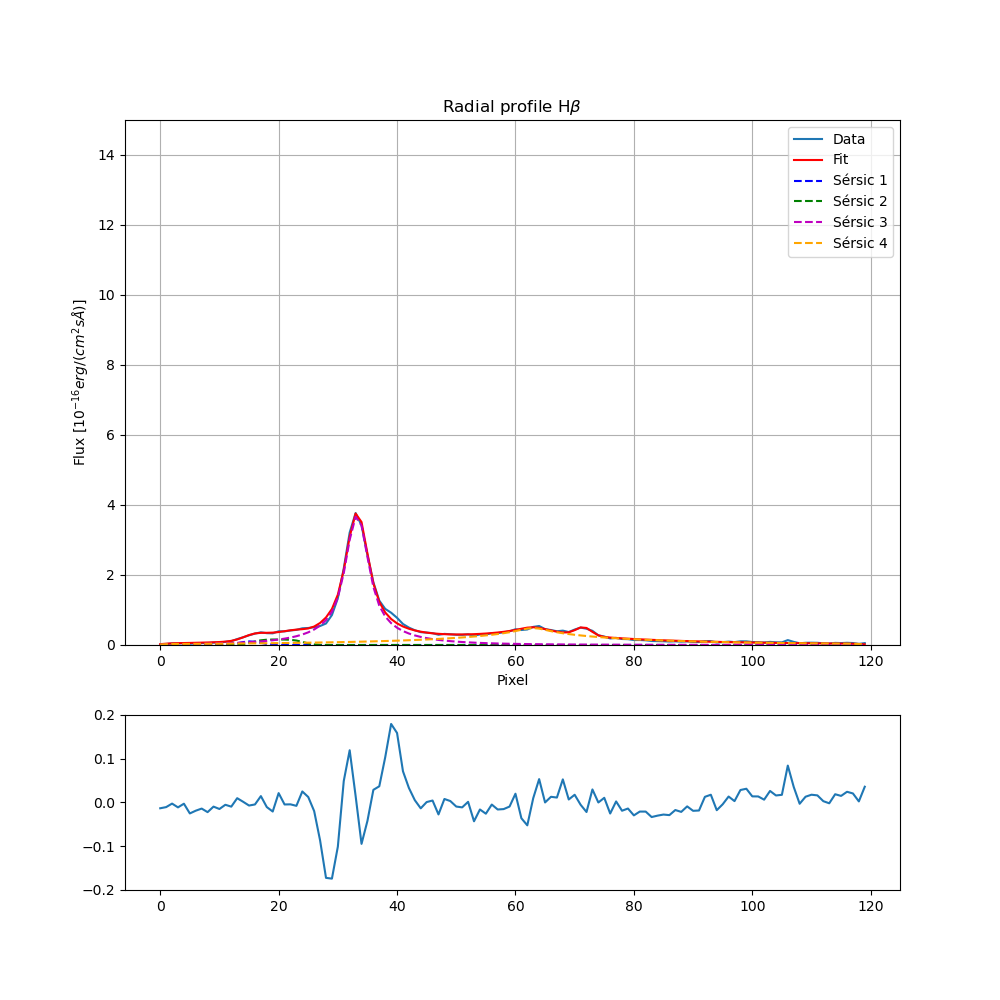

In [20]:
save_params_diff(best_params, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="HBeta", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_diff')

In [21]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HB, covariance_HB = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), 
                                           x_axes, radial_profile_HB, p0=result.x, sigma = real_errors_HB, bounds = bounds_list, maxfev = 10000)

print("Optimize parameters with curve fit:")
chi2_reduced_HB, dof_HB, chi2_HB = save_params(params_curve_HB, covariance_HB, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="Hbeta", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0995, r_e=1.4490, n=0.2423, x_0=14.9378
Sérsic 2: I_e=0.1537, r_e=3.9280, n=0.1066, x_0=20.0246
Sérsic 3: I_e=0.2223, r_e=10.4154, n=2.0787, x_0=33.4474
Sérsic 4: I_e=0.0422, r_e=49.6891, n=1.4635, x_0=62.9571
Sérsic 5: I_e=0.0851, r_e=1.3213, n=1.3311, x_0=71.4358
[3.04301650e-01 1.77066494e+00 3.85020726e+00 1.61524676e+00
 1.23349860e-01 4.64717813e+00 3.84465804e-01 3.66152021e+00
 6.45425384e-02 1.81303512e+00 4.06813815e-01 4.37678125e-03
 8.85677626e-03 8.03575107e+00 1.33876133e-01 4.33050160e-01
 3.81832577e-01 2.57843513e+00 4.47268410e+00 2.16228504e-01]
2.188136577566321


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15644\3155957358.py:43: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])


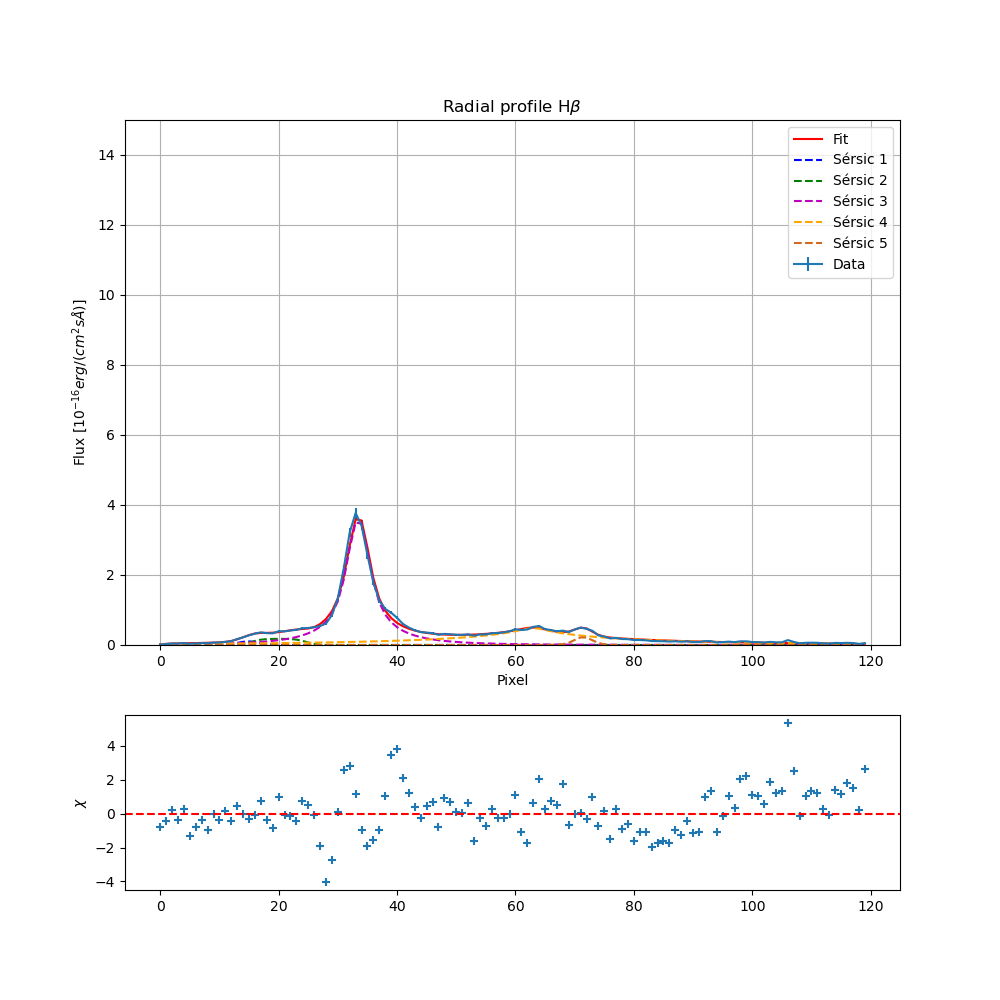

In [42]:
# Plots:
plot_curve(x_axes, params_curve_HB, radial_profile_HB, real_errors_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_curve')

## [NII]

Text(0.5, 1.0, '[NII]')

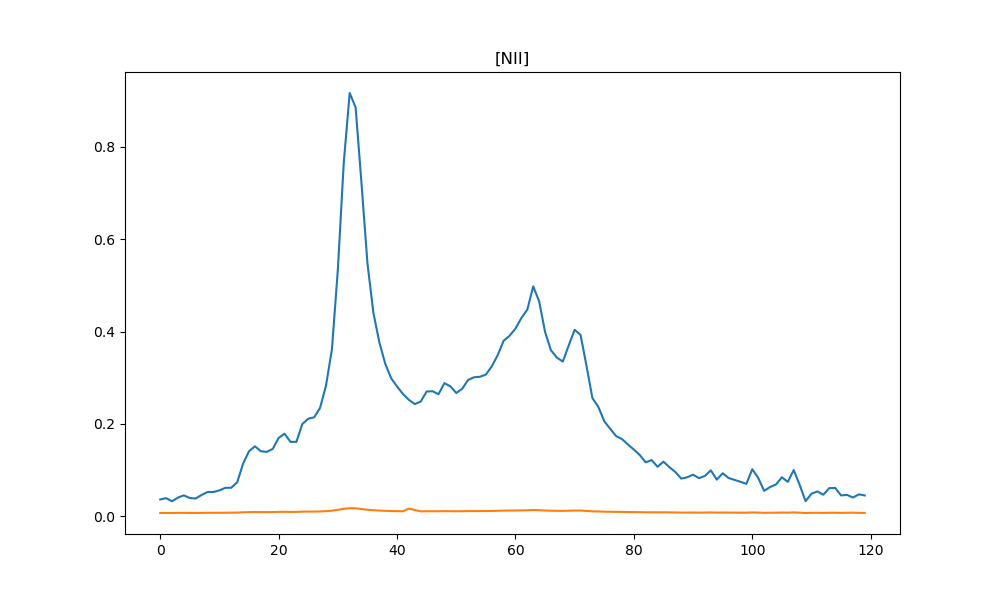

In [23]:
mask_NII = (wv > l_NII-8)*(wv < l_NII+8)
image_NII = image_cut[:, mask_NII]
image_error_NII = image_error_cut[:, mask_NII]
radial_profile_NII = np.sum(image_NII, axis = 1)
radial_profile_error_NII = np.sqrt(np.sum(image_error_NII**2, axis = 1))
real_errors_NII = np.sqrt(radial_profile_error_NII**2+(sky_err[2])**2+(0.04*radial_profile_NII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_NII)
plt.plot(x_axes, radial_profile_error_NII)
plt.title(r'[NII]')

In [24]:
# Bounds:
bounds = bounds
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_NII, sigmas[2])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 6347.594844994216
differential_evolution step 2: f(x)= 1086.0305993584361
differential_evolution step 3: f(x)= 1086.0305993584361
differential_evolution step 4: f(x)= 1086.0305993584361
differential_evolution step 5: f(x)= 1086.0305993584361
differential_evolution step 6: f(x)= 1086.0305993584361
differential_evolution step 7: f(x)= 1086.0305993584361
differential_evolution step 8: f(x)= 1086.0305993584361
differential_evolution step 9: f(x)= 1086.0305993584361
differential_evolution step 10: f(x)= 1086.0305993584361
differential_evolution step 11: f(x)= 1086.0305993584361
differential_evolution step 12: f(x)= 492.22888107423825
differential_evolution step 13: f(x)= 377.3942083454283
differential_evolution step 14: f(x)= 377.3942083454283
differential_evolution step 15: f(x)= 377.3942083454283
differential_evolution step 16: f(x)= 377.3942083454283
differential_evolution step 17: f(x)= 377.3942083454283
differential_evolution step 18: f(x)= 32.49847

Sérsic 1: I_e=0.0201, r_e=0.7477, n=2.2866, x_0=15.5682
Sérsic 2: I_e=0.1867, r_e=0.0896, n=1.5472, x_0=19.8591
Sérsic 3: I_e=0.0290, r_e=21.2123, n=2.3256, x_0=32.4654
Sérsic 4: I_e=0.0552, r_e=41.3771, n=1.2635, x_0=61.9374
Sérsic 5: I_e=0.0007, r_e=5.9313, n=8.2845, x_0=70.5405


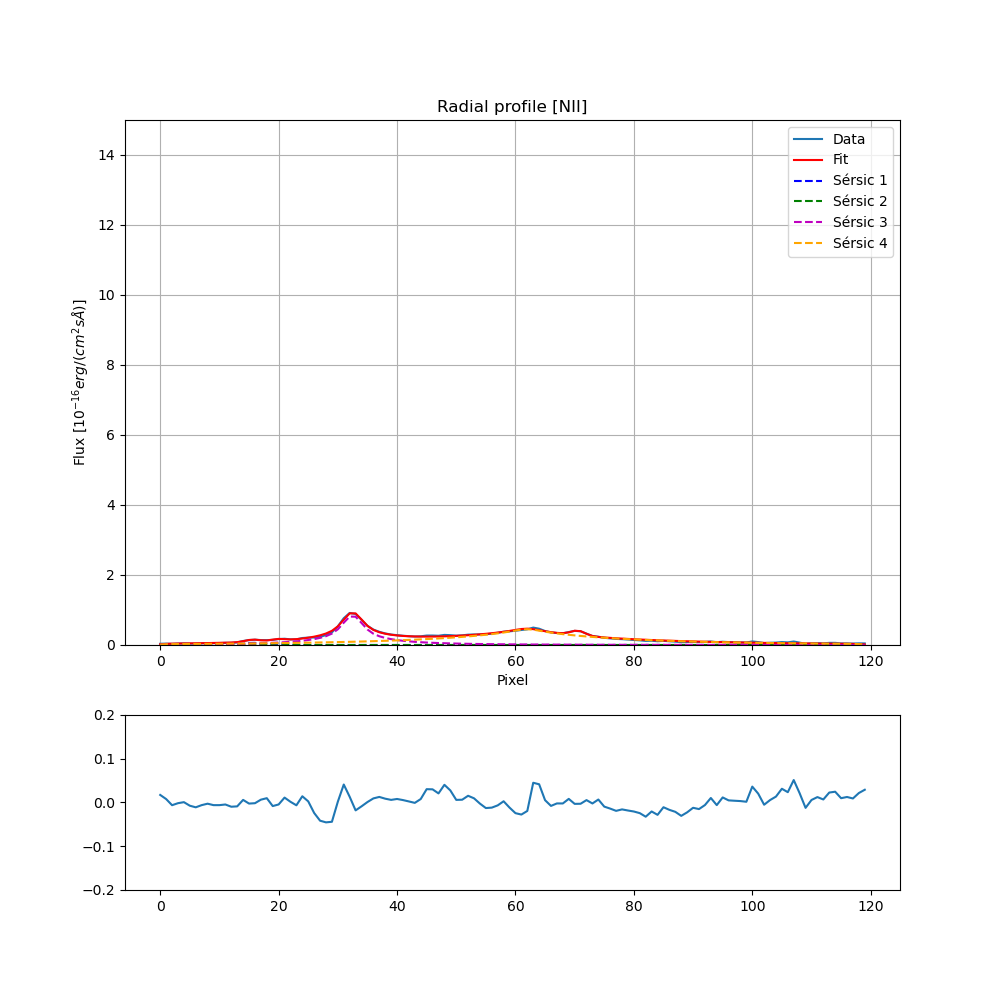

In [25]:
save_params_diff(best_params, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_diff')

In [26]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_NII, covariance_NII = curve_fit(lambda x, *params: model_convolved(x, sigmas[2], *params), x_axes, radial_profile_NII, 
                                             p0=result.x, sigma = real_errors_NII, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_NII, dof_NII, chi2_NII = save_params(params_curve_NII, covariance_NII, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0218, r_e=0.7365, n=2.2387, x_0=15.6401
Sérsic 2: I_e=0.1735, r_e=0.0994, n=1.5346, x_0=19.8898
Sérsic 3: I_e=0.0265, r_e=22.1799, n=2.3978, x_0=32.5546
Sérsic 4: I_e=0.0530, r_e=42.5440, n=1.2846, x_0=61.7533
Sérsic 5: I_e=0.0007, r_e=5.9288, n=8.2648, x_0=70.5381
[8.07410802e-01 1.09400103e+01 4.71228383e+01 4.06972132e-01
 1.25165487e+03 1.51342472e+01 1.54410802e+04 5.84918684e+00
 2.09853163e-02 1.25332268e+01 7.59363673e-01 2.38609766e-03
 8.00421844e-03 4.60767148e+00 8.85457647e-02 4.13349693e-01
 1.08791348e-01 5.10562462e+02 2.13073377e+02 1.73491301e-01]
1.4387816060417435


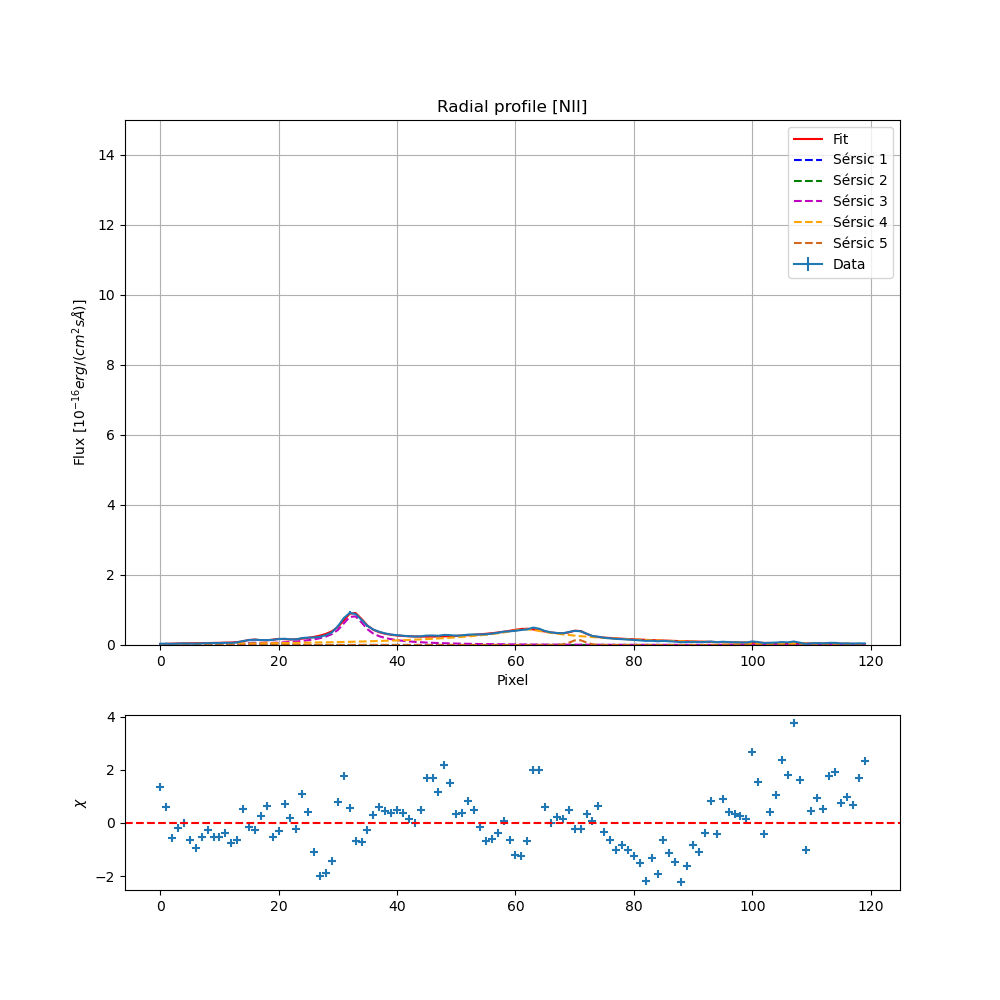

In [43]:
plot_curve(x_axes, params_curve_NII, radial_profile_NII, real_errors_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_curve')

## [SII]

Text(0.5, 1.0, '[SII]')

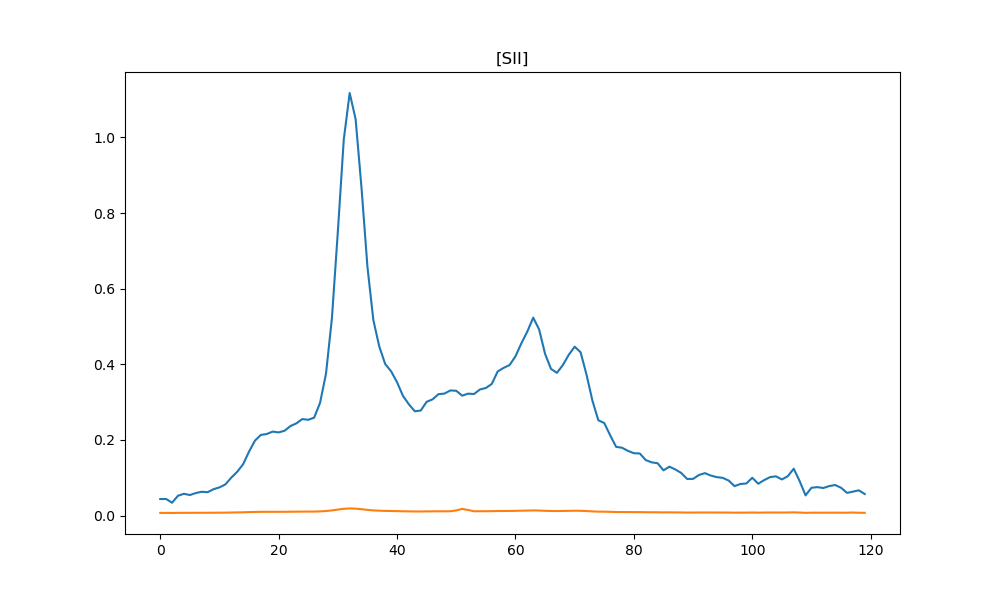

In [28]:
mask_SII = (wv > l_SII-8)*(wv < l_SII+8)
x_axes = np.arange(0, 120, 1)
image_SII = image_cut[:, mask_SII] 
image_error_SII = image_error_cut[:, mask_SII]
radial_profile_SII = np.sum(image_SII, axis = 1)
radial_profile_error_SII = np.sqrt(np.sum(image_error_SII**2, axis = 1))
real_errors_SII = np.sqrt(radial_profile_error_SII**2+(sky_err[2])**2+(0.04*radial_profile_SII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_SII)
plt.plot(x_axes, radial_profile_error_SII)
plt.title(r'[SII]')

In [29]:
# Bounds:
bounds = bounds
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_SII, sigmas[3])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 7228.659348267138
differential_evolution step 2: f(x)= 7228.659348267138
differential_evolution step 3: f(x)= 7228.659348267138
differential_evolution step 4: f(x)= 2427.372670509989
differential_evolution step 5: f(x)= 2427.372670509989
differential_evolution step 6: f(x)= 2427.372670509989
differential_evolution step 7: f(x)= 1725.7685935515162
differential_evolution step 8: f(x)= 1239.5626287921646
differential_evolution step 9: f(x)= 197.28731589298266
differential_evolution step 10: f(x)= 197.28731589298266
differential_evolution step 11: f(x)= 197.28731589298266
differential_evolution step 12: f(x)= 197.28731589298266
differential_evolution step 13: f(x)= 197.28731589298266
differential_evolution step 14: f(x)= 100.72849113174635
differential_evolution step 15: f(x)= 42.31972252733992
differential_evolution step 16: f(x)= 42.31972252733992
differential_evolution step 17: f(x)= 35.65222372396441
differential_evolution step 18: f(x)= 35.65222372

Sérsic 1: I_e=0.0393, r_e=1.6879, n=0.2530, x_0=16.0081
Sérsic 2: I_e=0.0454, r_e=2.9944, n=0.1052, x_0=19.2298
Sérsic 3: I_e=0.0378, r_e=21.4016, n=2.2696, x_0=32.2504
Sérsic 4: I_e=0.0519, r_e=49.9781, n=1.3212, x_0=62.1530
Sérsic 5: I_e=0.1515, r_e=1.3428, n=0.1328, x_0=70.4397


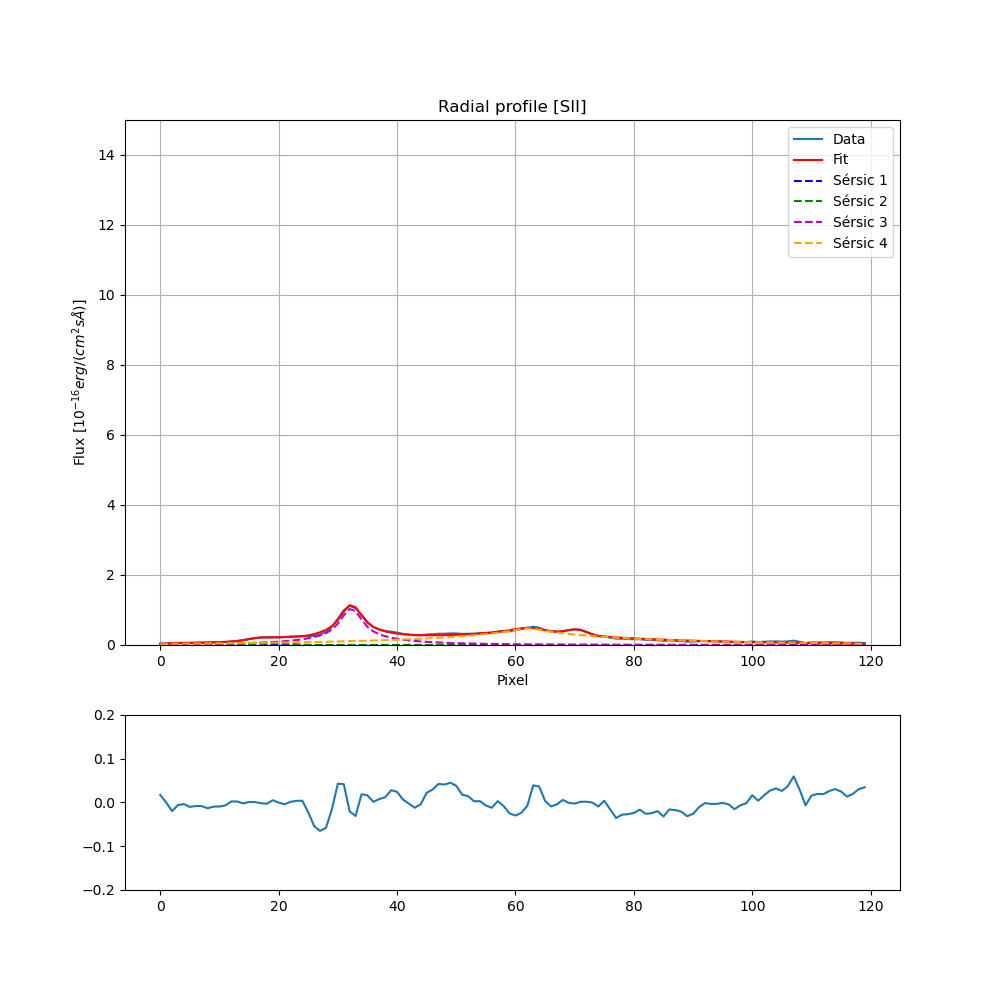

In [30]:
save_params_diff(best_params, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_diff')

In [31]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_SII, covariance_SII = curve_fit(lambda x, *params: model_convolved(x, sigmas[3], *params), x_axes, 
                                             radial_profile_SII, p0=result.x, sigma = real_errors_SII, bounds = bounds_list)

print("Optimize parameters with curve fit:")
chi2_reduced_SII, dof_SII, chi2_SII = save_params(params_curve_SII, covariance_SII, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0333, r_e=2.0229, n=0.2495, x_0=16.0182
Sérsic 2: I_e=0.0484, r_e=3.4365, n=0.1000, x_0=19.2580
Sérsic 3: I_e=0.0388, r_e=19.8967, n=2.2744, x_0=32.3726
Sérsic 4: I_e=0.0527, r_e=50.0000, n=1.3018, x_0=61.7444
Sérsic 5: I_e=0.1377, r_e=1.3916, n=0.2633, x_0=70.3690
[6.87652496e-02 2.83217184e+00 1.97107481e+00 2.72807747e+00
 2.09729718e-01 1.76722986e+01 1.36536649e+00 1.95508530e+00
 1.66847228e-02 6.73348554e+00 3.21416964e-01 9.13874570e-02
 7.37278880e-03 5.61398210e+00 9.11715144e-02 3.93118294e-01
 2.45548569e-01 4.18902914e-01 1.60396965e+00 2.80956348e-01]
2.0002415884882954


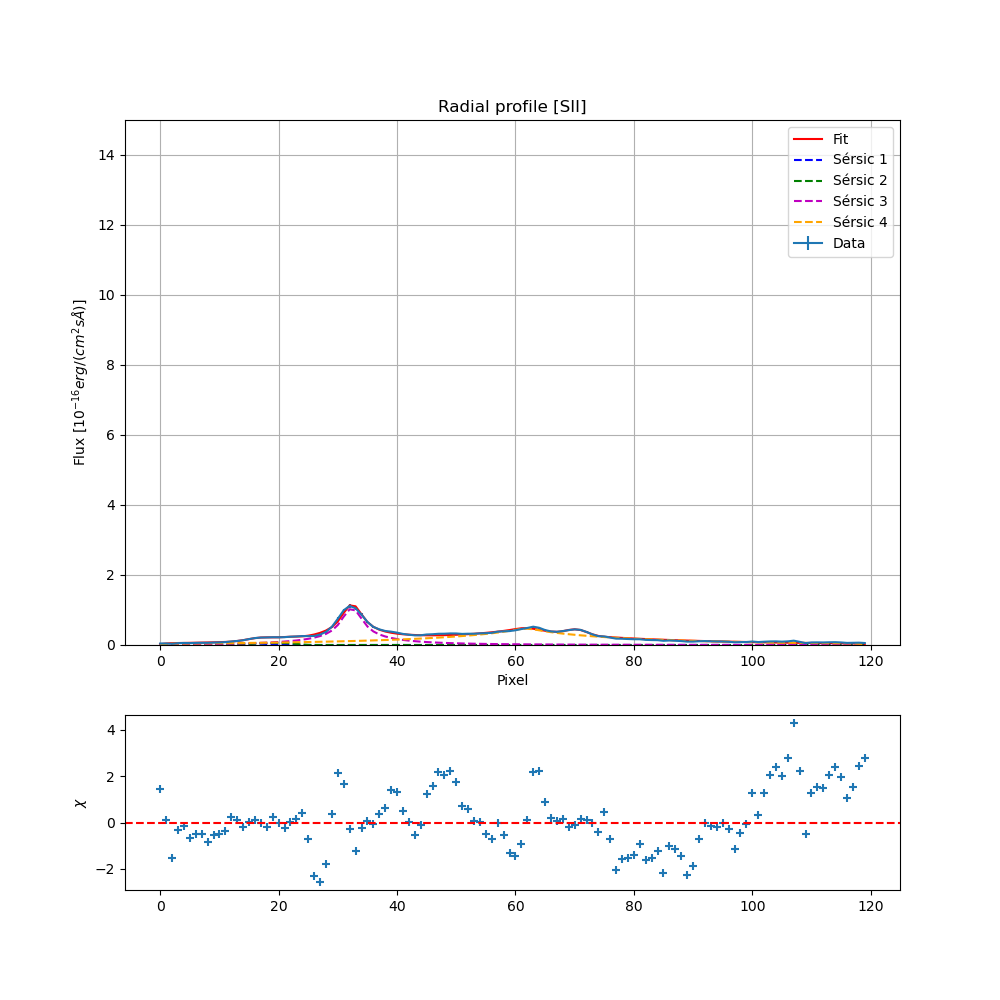

In [32]:
# Plots:
plot_curve(x_axes, params_curve_SII, radial_profile_SII, real_errors_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_curve')

## [OIII]

Text(0.5, 1.0, '[OIII]')

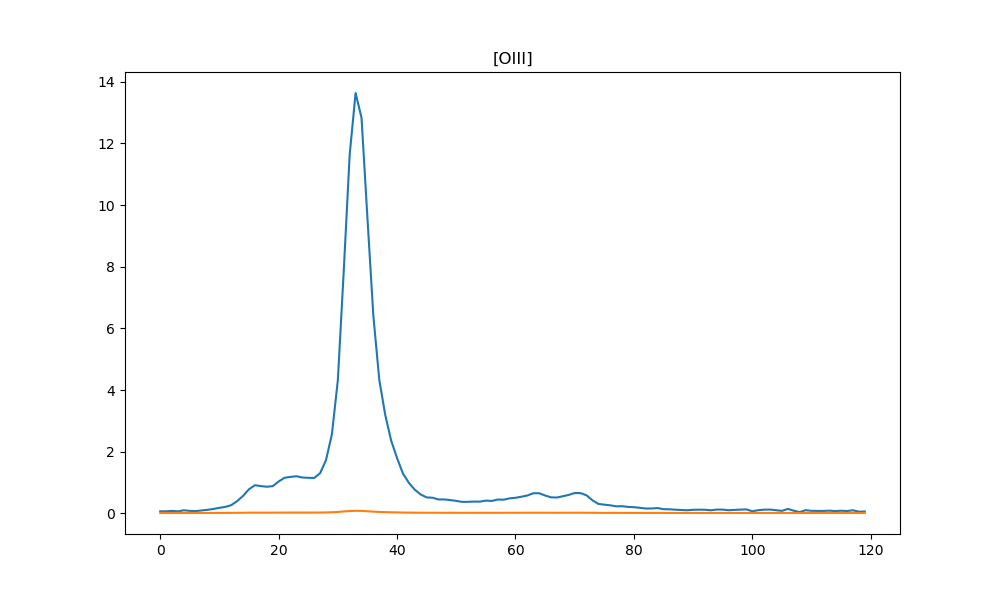

In [44]:
mask_OIII = (wv > l_OIII-8)*(wv < l_OIII+8)
image_OIII = image_cut[:, mask_OIII] 
image_error_OIII = image_error_cut[:, mask_OIII]
radial_profile_OIII = np.sum(image_OIII, axis = 1)
radial_profile_error_OIII = np.sqrt(np.sum(image_error_OIII**2, axis = 1))
real_errors_OIII = np.sqrt(radial_profile_error_OIII**2+(sky_err[2])**2+(0.04*radial_profile_OIII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_OIII)
plt.plot(x_axes, radial_profile_error_OIII)
plt.title(r'[OIII]')

In [45]:
# Bounds:
bounds =[
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 3),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1, x_0_HA[0]+1),   # x_0: circa la posizione di Halpha

    (0, 1),
    (0, 3),
    (0.1, 10),
    (x_0_HA[1]-1, x_0_HA[1]+1),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1, x_0_HA[2]+1),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-seeing[-1]/2, x_0_HA[3]+seeing[-1]/2),

     (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[4]-seeing[-1]/2, x_0_HA[4]+seeing[-1]/2),
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_OIII, sigmas[4])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 12856.816261752218
differential_evolution step 2: f(x)= 8051.5599888696715
differential_evolution step 3: f(x)= 8051.5599888696715
differential_evolution step 4: f(x)= 2883.108283693552
differential_evolution step 5: f(x)= 2338.8137530257327
differential_evolution step 6: f(x)= 1908.750237256273
differential_evolution step 7: f(x)= 1908.750237256273
differential_evolution step 8: f(x)= 494.6006525729739
differential_evolution step 9: f(x)= 494.6006525729739
differential_evolution step 10: f(x)= 494.6006525729739
differential_evolution step 11: f(x)= 494.6006525729739
differential_evolution step 12: f(x)= 126.867895510888
differential_evolution step 13: f(x)= 126.867895510888
differential_evolution step 14: f(x)= 126.867895510888
differential_evolution step 15: f(x)= 126.867895510888
differential_evolution step 16: f(x)= 68.29682387336346
differential_evolution step 17: f(x)= 68.29682387336346
differential_evolution step 18: f(x)= 68.29682387336346
d

Sérsic 1: I_e=0.1055, r_e=2.3472, n=1.7284, x_0=14.9382
Sérsic 2: I_e=0.6508, r_e=3.0000, n=0.1283, x_0=20.3838
Sérsic 3: I_e=1.7024, r_e=5.5521, n=1.6504, x_0=33.2864
Sérsic 4: I_e=0.0609, r_e=49.7545, n=1.3791, x_0=62.7310
Sérsic 5: I_e=0.3392, r_e=1.2393, n=0.1757, x_0=70.5385


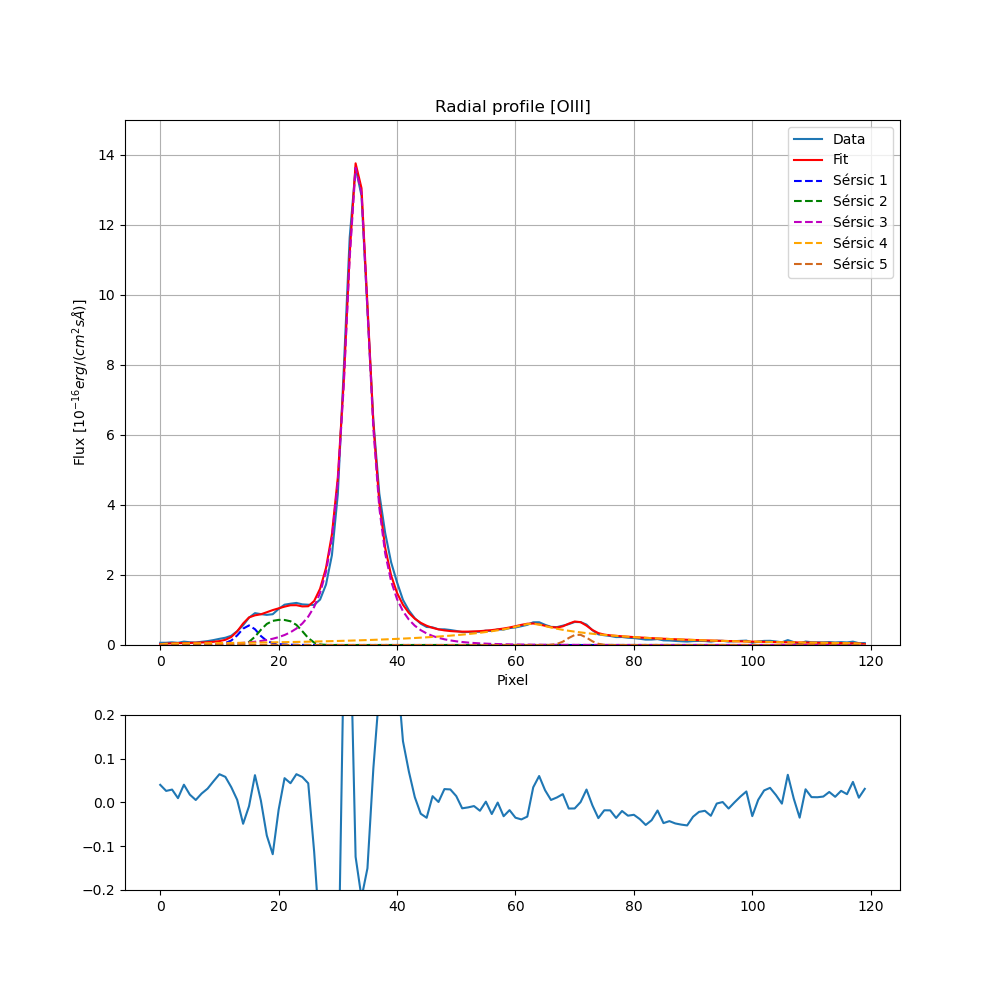

In [46]:
save_params_diff(best_params, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_diff')

In [47]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_OIII, covariance_OIII = curve_fit(lambda x, *params: model_convolved(x, sigmas[4], *params), x_axes, radial_profile_OIII, 
                                               p0=result.x, sigma = real_errors_OIII, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_OIII, dof_OIII, chi2_OIII = save_params(params_curve_OIII, covariance_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.1059, r_e=3.0000, n=1.3428, x_0=14.8894
Sérsic 2: I_e=0.5880, r_e=3.0000, n=0.1768, x_0=20.3838
Sérsic 3: I_e=1.2633, r_e=6.4600, n=1.9233, x_0=33.4950
Sérsic 4: I_e=0.0529, r_e=50.0000, n=1.4501, x_0=62.9571
Sérsic 5: I_e=0.3260, r_e=1.6121, n=0.1004, x_0=70.5149
[2.35270557e-01 2.04826130e+00 1.35387004e+00 1.79585654e+00
 1.22630339e-01 1.14398950e+00 2.75406684e-01 1.71128185e+00
 1.76046450e-01 4.95203373e-01 1.38500093e-01 5.66754028e-02
 1.22945218e-02 8.79041107e+00 1.48706857e-01 4.43415604e-01
 3.06090331e+00 1.89076940e+01 3.30028154e+00 2.30201285e-01]
3.1937786112044897


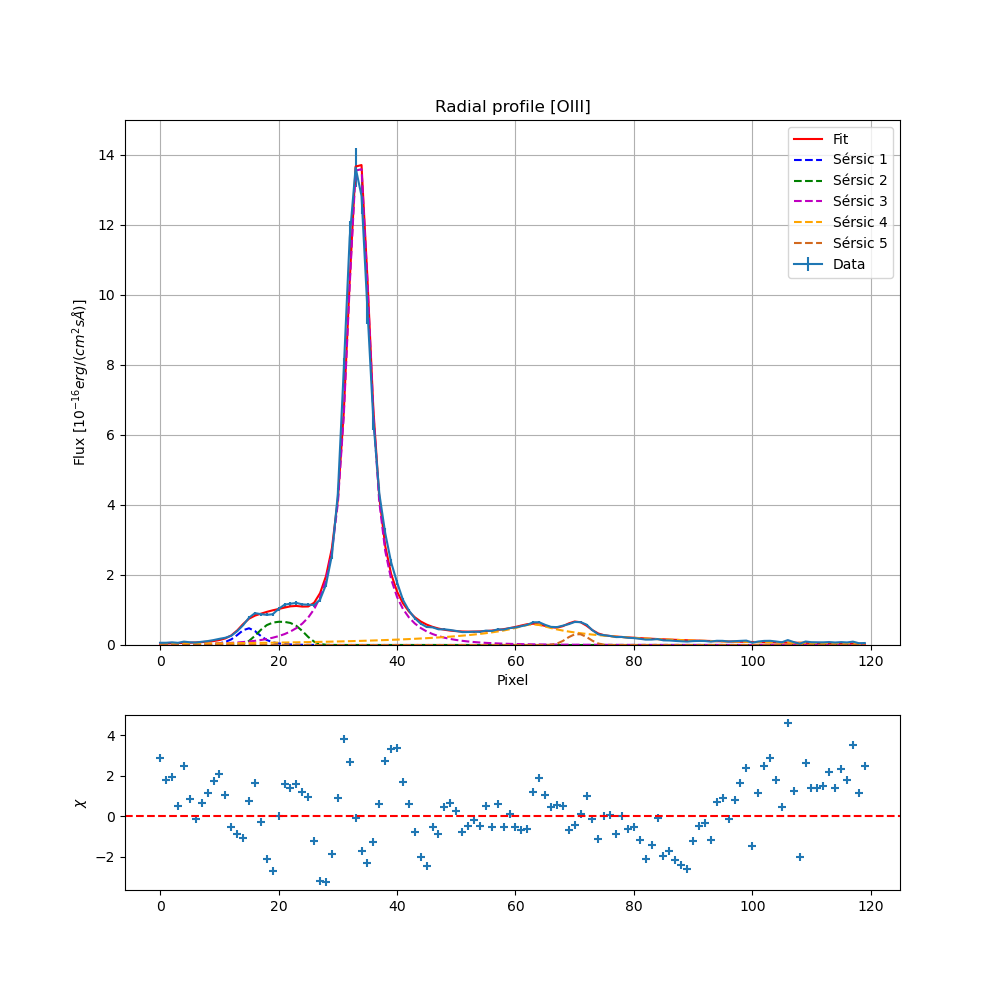

In [48]:
plot_curve(x_axes, params_curve_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_curve')

In [49]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)

## Continuum 1

In [ ]:
mask_continuum_1 = (wv > 4500)*(wv < 4800)
image_continuum_1 = image_cut[:, mask_continuum_1]
image_error_continuum_1 = image_error_cut[:, mask_continuum_1]
radial_profile_continuum_1 = np.sum(image_continuum_1, axis = 1)
radial_profile_error_continuum_1 = np.sqrt(np.sum(image_error_continuum_1**2, axis = 1))
real_errors_c1 = np.sqrt(radial_profile_error_continuum_1**2+(sky_err[2])**2+(0.04*radial_profile_continuum_1)**2)

x_axes = np.arange(0, 120, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_1)
plt.plot(x_axes, radial_profile_error_continuum_1)
plt.title(r'Continuum 1')

In [ ]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_1, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

In [ ]:
def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 30)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 30)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

In [ ]:
save_params_diff(best_params, radial_profile_continuum_1, real_errors_c1, sigmas[1],
    x_axes, n_component, line_name="Continuum_1", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_diff')

In [ ]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))

params_curve_continuum_1, covariance_continuum_1 = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), x_axes,
                                                             radial_profile_continuum_1, p0=result.x, sigma = real_errors_c1, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_1, dof_continuum_1, chi2_continuum_1 = save_params(params_curve_continuum_1, covariance_continuum_1, 
                                                                          radial_profile_continuum_1, real_errors_c1, sigmas[1],
                                                                          x_axes, n_component, line_name="Continuum_1", output_prefix="fit")

In [ ]:
# Plots:
plot_curve(x_axes, params_curve_continuum_1, radial_profile_continuum_1, real_errors_c1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_curve')

## Continuum 2 

In [ ]:
mask_continuum_2 = (wv > 5100)*(wv < 5400)
image_continuum_2 = image_cut[:, mask_continuum_2]
image_error_continuum_2 = image_error_cut[:, mask_continuum_2]
radial_profile_continuum_2 = np.sum(image_continuum_2, axis = 1)
radial_profile_error_continuum_2 = np.sqrt(np.sum(image_error_continuum_2**2, axis = 1))
real_errors_c2 = np.sqrt(radial_profile_error_continuum_2**2+(sky_err[2])**2+(0.04*radial_profile_continuum_2)**2)

x_axes = np.arange(0, 120, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_2)
plt.plot(x_axes, radial_profile_error_continuum_2)
plt.title(r'Continuum 2')

In [ ]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_2, sigmas[5])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

In [ ]:
save_params_diff(best_params, radial_profile_continuum_2, real_errors_c2, sigmas[-1],
    x_axes, n_component, line_name="Continuum_2", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_2, sigmas[-1], r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_diff')

In [ ]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_2, covariance_continuum_2 = curve_fit(lambda x, *params: model_convolved(x, sigmas[-1], *params), x_axes, radial_profile_continuum_2, p0=result.x, 
                                                             sigma = real_errors_c2, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_2, dof_continuum_2, chi2_continuum_2 = save_params(params_curve_continuum_2, covariance_continuum_2, radial_profile_continuum_2,
                                                                          real_errors_c2, sigmas[-1], x_axes, n_component, line_name="Continuum_2", output_prefix="fit")

In [ ]:
plot_curve(x_axes, params_curve_continuum_2, radial_profile_continuum_2, real_errors_c2, sigmas[-1], r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_curve')

##  Continuum 3

In [ ]:
mask_continuum_3 = (wv > 5910)*(wv < 6210)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))
real_errors_c3 = np.sqrt(radial_profile_error_continuum_3**2+(sky_err[2])**2+(0.04*radial_profile_continuum_3)**2)

x_axes = np.arange(0, 120, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_3)
plt.plot(x_axes, radial_profile_error_continuum_3)
plt.title(r'Continuum 3')

In [ ]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_3, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

In [ ]:
save_params_diff(best_params, radial_profile_continuum_3, real_errors_c3, sigmas[0],
    x_axes, n_component, line_name="Continuum_3", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_diff')

In [ ]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_3, covariance_continuum_3 = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes,
                                                             radial_profile_continuum_3, p0=result.x, sigma = real_errors_c3) #, bounds = bounds_list, maxfev = 10000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_3, dof_continuum_3, chi2_continuum_3 = save_params(params_curve_continuum_3, covariance_continuum_3, radial_profile_continuum_3,
                                                                          real_errors_c3, sigmas[0], x_axes, n_component, line_name="Continuum_3", output_prefix="fit")

In [ ]:
plot_curve(x_axes, params_curve_continuum_3, radial_profile_continuum_3, real_errors_c3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_curve')

## Chi squared save

In [ ]:
chi_red = [chi2_reduced_continuum_1, chi2_reduced_continuum_2, chi2_reduced_continuum_3]
dof = [dof_continuum_1, dof_continuum_2, dof_continuum_3]
chi = [chi2_continuum_1, chi2_continuum_2, chi2_continuum_3]

d1 = {'Name': ['Continuum 1', 'Continuum 2', 'Continuum 3'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit_continuum.csv", index= False)